# KNN: Train/Test vs K-Fold vs Leave-One-Out (Wine)
Comparacion simple del error para k=1..15 con dataset de sklearn.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X, y = load_wine(return_X_y=True)
k_values = range(1, 16)
error_split, error_kfold, error_loo = [], [], []

loo = LeaveOneOut()

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)

    knn.fit(X_train, y_train)
    error_split.append(1 - knn.score(X_test, y_test))

    error_kfold.append(1 - cross_val_score(knn, X, y, cv=5, scoring='accuracy').mean())

    error_loo.append(1 - cross_val_score(knn, X, y, cv=loo, scoring='accuracy').mean())

In [ ]:
%matplotlib inline

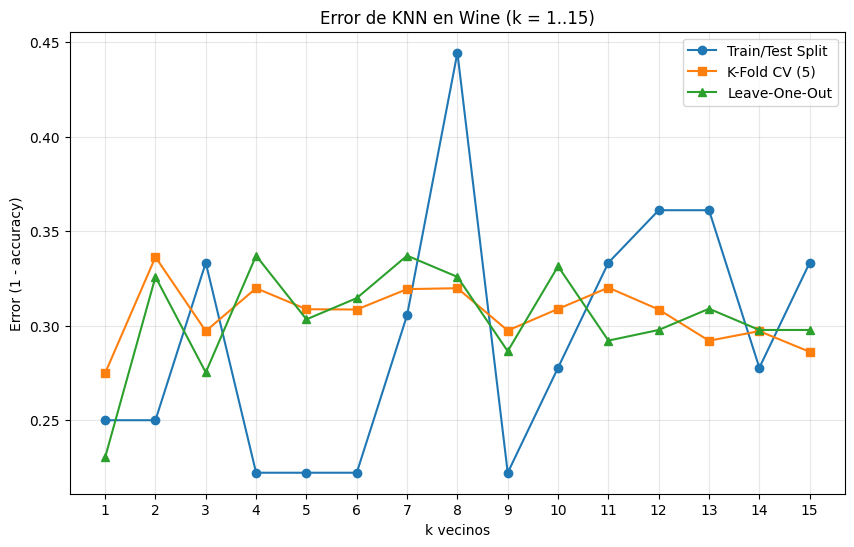

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(list(k_values), error_split, marker='o', label='Train/Test Split')
plt.plot(list(k_values), error_kfold, marker='s', label='K-Fold CV (5)')
plt.plot(list(k_values), error_loo, marker='^', label='Leave-One-Out')

plt.title('Error de KNN en Wine (k = 1..15)')
plt.xlabel('k vecinos')
plt.ylabel('Error (1 - accuracy)')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
print('k | split | kfold | loo')
for i, k in enumerate(k_values):
    print(f'{k:2d} | {error_split[i]:.4f} | {error_kfold[i]:.4f} | {error_loo[i]:.4f}')

k | split | kfold | loo
 1 | 0.3056 | 0.2749 | 0.2303
 2 | 0.2500 | 0.3363 | 0.3258
 3 | 0.3056 | 0.2971 | 0.2753
 4 | 0.2778 | 0.3198 | 0.3371
 5 | 0.2778 | 0.3087 | 0.3034
 6 | 0.2778 | 0.3086 | 0.3146
 7 | 0.3056 | 0.3194 | 0.3371
 8 | 0.3056 | 0.3198 | 0.3258
 9 | 0.2778 | 0.2975 | 0.2865
10 | 0.4444 | 0.3089 | 0.3315
11 | 0.3333 | 0.3202 | 0.2921
12 | 0.3056 | 0.3086 | 0.2978
13 | 0.2500 | 0.2921 | 0.3090
14 | 0.3333 | 0.2971 | 0.2978
15 | 0.3056 | 0.2862 | 0.2978
